<a href="https://colab.research.google.com/github/Kunj-7007/AI_ML_Workshop_LDRP/blob/day2/ML_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree


In [ ]:
#Load the dataset
data=pd.read_csv('/content/Renewable_Energy_Adoption.csv')
#display first few rows
print (data.head())
print(data.shape)

   carbon_emissions  energy_output  renewability_index  cost_efficiency  \
0        181.089042     128.286267            0.642032         0.732568   
1        382.750007     672.769370            0.084140         2.891096   
2        306.197880     382.920383            0.161629         2.932858   
3        259.530469     557.713622            0.898554         3.368435   
4        104.606524     916.809826            0.606429         3.767411   

   adoption  
0         1  
1         0  
2         0  
3         0  
4         0  
(100, 5)


In [ ]:
#Define features and target variable
x=data[['carbon_emissions','energy_output','renewability_index','cost_efficiency']]
y=data['adoption']  #1 for effective reduction , 0 otherwise

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [ ]:
model=DecisionTreeClassifier()

# The train_test_split in cell X1Vw3pck6RKR has been corrected,
# so y_train now holds the correct training labels.
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

In [ ]:
#Accurracy
accuracy_score=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy_score}")

Accuracy: 0.9


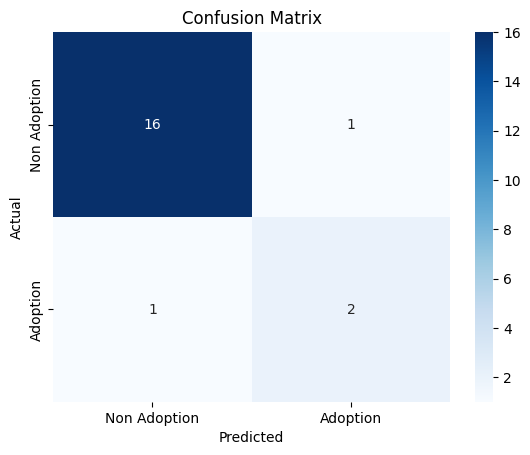

In [ ]:
#Confusion matirx
conf_matrix=confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Non Adoption','Adoption'],
            yticklabels=['Non Adoption','Adoption']
            )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Classification report
print (classification_report(y_test,y_pred , target_names=['Non Adoption','Adoption']))

              precision    recall  f1-score   support

Non Adoption       0.94      0.94      0.94        17
    Adoption       0.67      0.67      0.67         3

    accuracy                           0.90        20
   macro avg       0.80      0.80      0.80        20
weighted avg       0.90      0.90      0.90        20



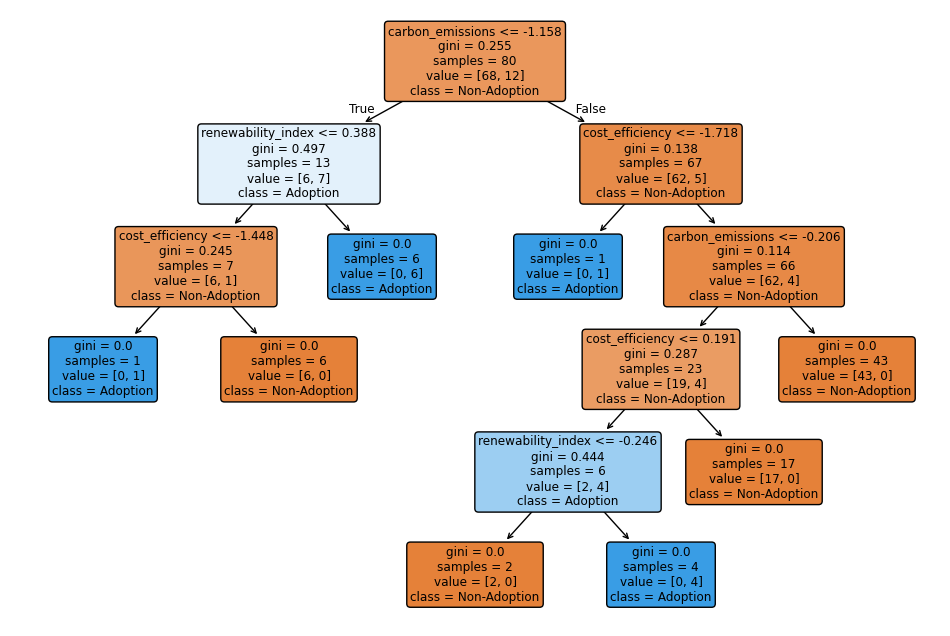

In [ ]:
#decision Tree
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=x.columns, class_names=['Non-Adoption', 'Adoption'], filled=True, rounded=True)
plt.savefig('desision_tree.png')
plt.show()